# Exploratory Data Analysis (EDA) - News Sentiment for Price Prediction

This notebook performs comprehensive exploratory data analysis on the news sentiment dataset to understand:
- Descriptive Statistics
- Text Analysis and Topic Modeling
- Time Series Analysis
- Publisher Analysis

## Table of Contents
1. [Data Loading and Initial Exploration](#data-loading)
2. [Descriptive Statistics](#descriptive-stats)
3. [Text Analysis and Topic Modeling](#text-analysis)
4. [Time Series Analysis](#time-series)
5. [Publisher Analysis](#publisher-analysis)
6. [Key Insights and Conclusions](#conclusions)

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Text processing libraries
import re
from collections import Counter
try:
    from wordcloud import WordCloud
except ImportError:
    print('WordCloud not available, install with: pip install wordcloud')
    
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans

# Time series analysis
from datetime import datetime, timedelta
import calendar

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. Data Loading and Initial Exploration {#data-loading}

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw_analyst_ratings.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1407328, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First few rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB
None

Missing Values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Data Types:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object


In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
# Extract additional time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.dayofweek
df['hour'] = df['date'].dt.hour
df['weekday_name'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.month_name()

# Calculate headline length
df['headline_length'] = df['headline'].str.len()
df['headline_word_count'] = df['headline'].str.split().str.len()

print("Date processing completed!")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total records with valid dates: {df['date'].notna().sum():,}")


Date processing completed!
Date range: 2020-05-22 08:06:17-04:00 to 2020-06-05 10:30:54-04:00
Total records with valid dates: 172


## 2. Descriptive Statistics {#descriptive-stats}

In [7]:
# Basic statistics for headline lengths
print("HEADLINE LENGTH STATISTICS")
print("="*40)
print(df['headline_length'].describe())
print("\nHEADLINE WORD COUNT STATISTICS")
print("="*40)
print(df['headline_word_count'].describe())

HEADLINE LENGTH STATISTICS
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

HEADLINE WORD COUNT STATISTICS
count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_word_count, dtype: float64


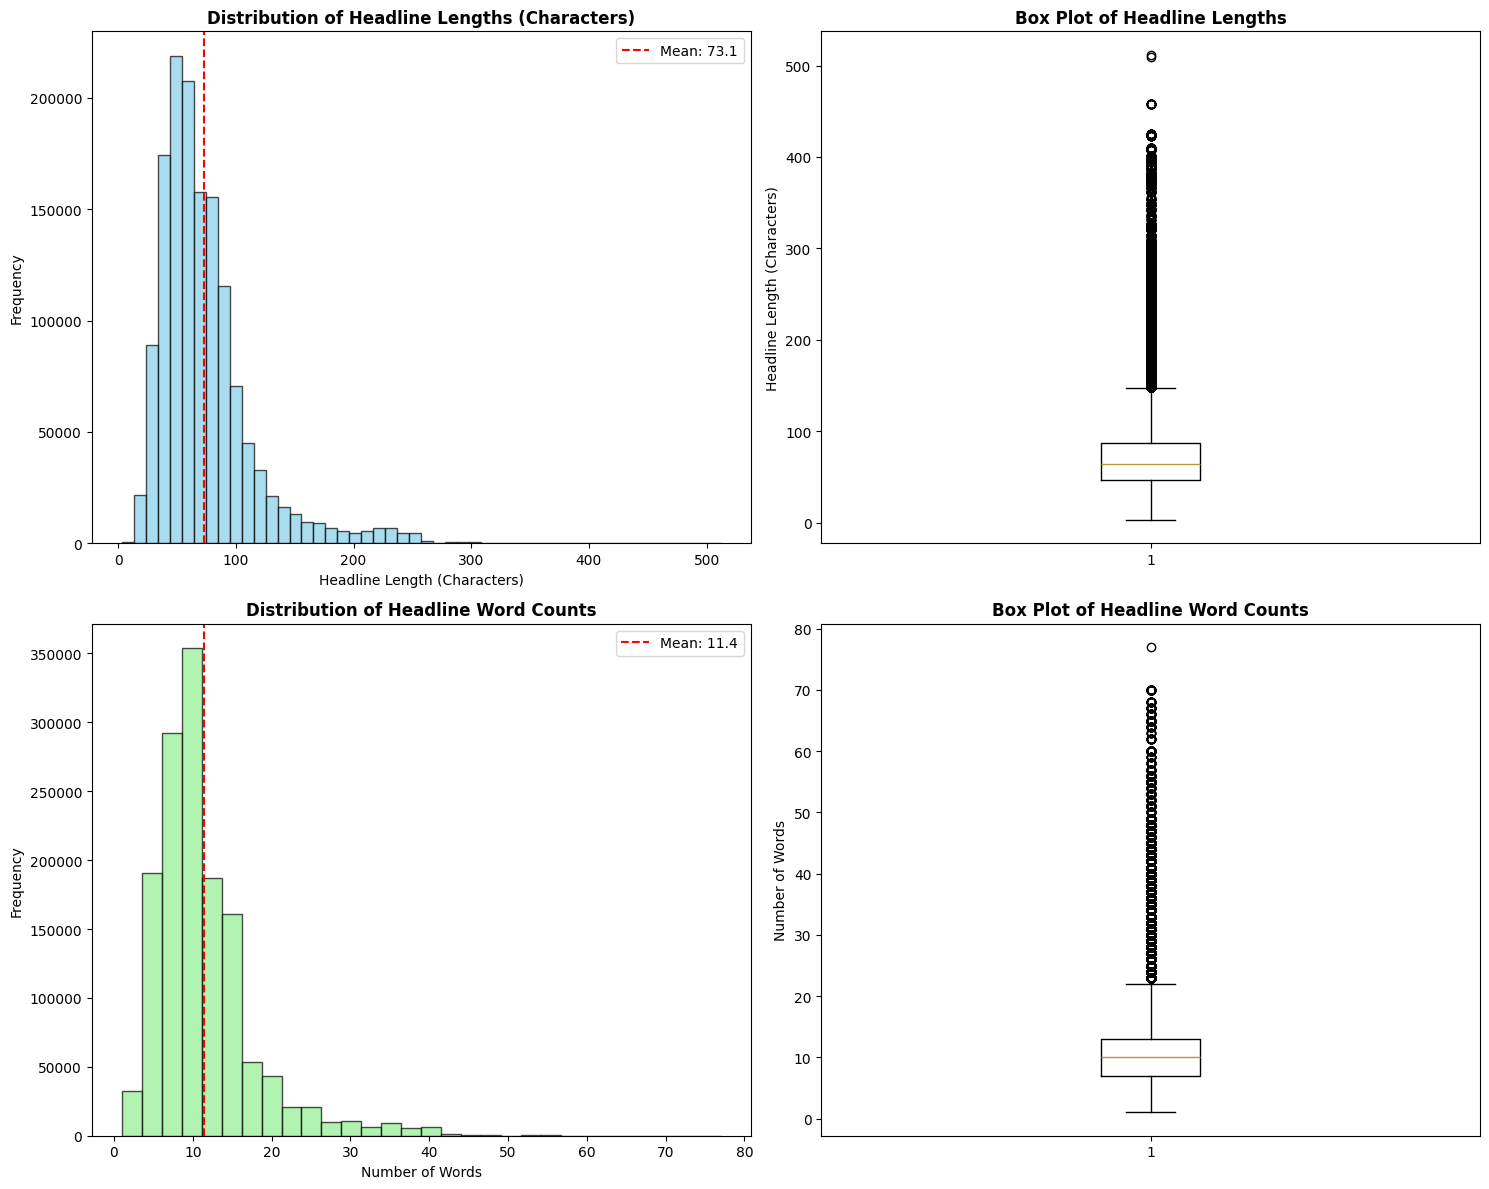

In [8]:
# Visualization of headline lengths
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of headline lengths
axes[0, 0].hist(df['headline_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Headline Lengths (Characters)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Headline Length (Characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_length"].mean():.1f}')
axes[0, 0].legend()

# Box plot of headline lengths
axes[0, 1].boxplot(df['headline_length'])
axes[0, 1].set_title('Box Plot of Headline Lengths', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Headline Length (Characters)')

# Histogram of word counts
axes[1, 0].hist(df['headline_word_count'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Headline Word Counts', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Words')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['headline_word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_word_count"].mean():.1f}')
axes[1, 0].legend()

# Box plot of word counts
axes[1, 1].boxplot(df['headline_word_count'])
axes[1, 1].set_title('Box Plot of Headline Word Counts', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Words')

plt.tight_layout()
plt.show()

TOP 20 MOST ACTIVE PUBLISHERS
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


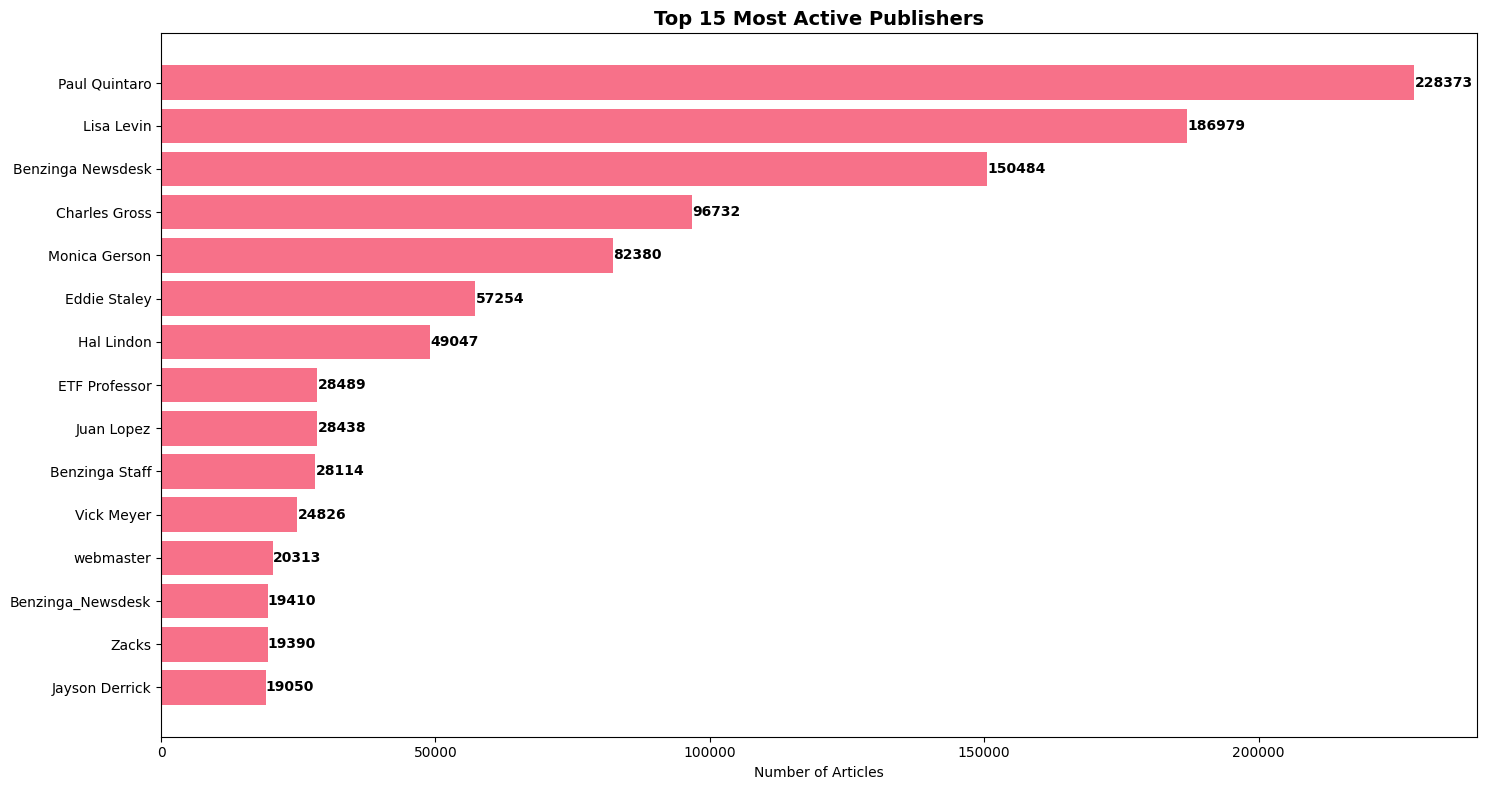

In [9]:
# Articles per publisher
publisher_counts = df['publisher'].value_counts()
print("TOP 20 MOST ACTIVE PUBLISHERS")
print("="*40)
print(publisher_counts.head(20))

# Visualization
plt.figure(figsize=(15, 8))
top_publishers = publisher_counts.head(15)
plt.barh(range(len(top_publishers)), top_publishers.values)
plt.yticks(range(len(top_publishers)), top_publishers.index)
plt.xlabel('Number of Articles')
plt.title('Top 15 Most Active Publishers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_publishers.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

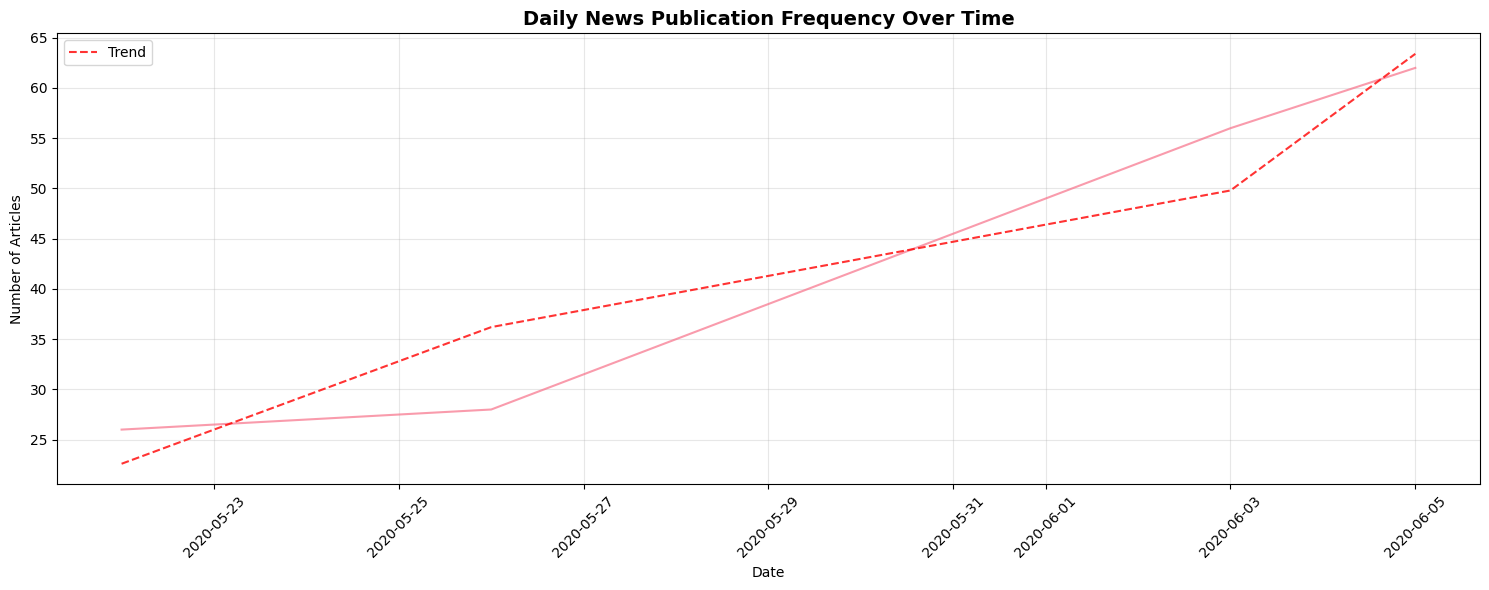

Average daily articles: 43.0
Max daily articles: 62 on 2020-06-05
Min daily articles: 26 on 2020-05-22


In [10]:
# Publication trends over time
# Daily publication counts
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15, 6))
plt.plot(daily_counts.index, daily_counts.values, alpha=0.7)
plt.title('Daily News Publication Frequency Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(daily_counts)), daily_counts.values, 1)
p = np.poly1d(z)
plt.plot(daily_counts.index, p(range(len(daily_counts))), "r--", alpha=0.8, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average daily articles: {daily_counts.mean():.1f}")
print(f"Max daily articles: {daily_counts.max()} on {daily_counts.idxmax()}")
print(f"Min daily articles: {daily_counts.min()} on {daily_counts.idxmin()}")

## 3. Text Analysis and Topic Modeling {#text-analysis}

In [11]:
# Text preprocessing function
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd
import re

# Initialize once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing headlines...")
df['headline_processed'] = df['headline'].apply(preprocess_text)
print("Preprocessing completed!")


Preprocessing headlines...
Preprocessing completed!


In [12]:
# Word frequency analysis
all_words = ' '.join(df['headline_processed']).split()
word_freq = Counter(all_words)

print("TOP 30 MOST COMMON WORDS")
print("="*40)
for word, count in word_freq.most_common(30):
    print(f"{word}: {count}")

TOP 30 MOST COMMON WORDS
stock: 201100
share: 146182
est: 140660
eps: 128929
report: 124503
market: 120900
update: 93394
earnings: 87185
sale: 85320
top: 81280
price: 74211
week: 70774
buy: 68661
lower: 68095
announces: 66529
company: 65424
downgrade: 63812
trading: 61165
raise: 59896
upgrade: 58999
benzingas: 57985
target: 56343
maintains: 52961
etf: 50029
estimate: 49942
higher: 48163
new: 48061
session: 45810
inc: 45115
say: 44275


In [13]:
# Word cloud visualization (if available)
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=1200, height=600, 
                         background_color='white',
                         max_words=100,
                         colormap='viridis').generate(' '.join(df['headline_processed']))

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Headlines', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("WordCloud not available. Install with: pip install wordcloud")
    # Create a simple bar chart instead
    top_words = word_freq.most_common(20)
    words, counts = zip(*top_words)
    
    plt.figure(figsize=(12, 8))
    plt.barh(words, counts)
    plt.xlabel('Frequency')
    plt.title('Top 20 Most Common Words in Headlines', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

: 

In [ ]:
# Financial keywords analysis
financial_keywords = [
    'fda approval', 'price target', 'earnings', 'revenue', 'profit', 'loss',
    'acquisition', 'merger', 'ipo', 'dividend', 'buyback', 'guidance',
    'upgrade', 'downgrade', 'analyst', 'rating', 'recommendation',
    'bull', 'bear', 'rally', 'selloff', 'volatility', 'volume'
]

keyword_counts = {}
for keyword in financial_keywords:
    count = df['headline'].str.lower().str.contains(keyword, na=False).sum()
    if count > 0:
        keyword_counts[keyword] = count

# Sort by frequency
keyword_counts = dict(sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True))

print("FINANCIAL KEYWORDS FREQUENCY")
print("="*40)
for keyword, count in keyword_counts.items():
    print(f"{keyword}: {count}")

# Visualization
if keyword_counts:
    plt.figure(figsize=(12, 6))
    keywords = list(keyword_counts.keys())[:15]
    counts = list(keyword_counts.values())[:15]
    
    plt.barh(keywords, counts)
    plt.xlabel('Frequency')
    plt.title('Financial Keywords in Headlines', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    for i, v in enumerate(counts):
        plt.text(v + 1, i, str(v), va='center')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Topic modeling using LDA
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5)
tfidf_matrix = vectorizer.fit_transform(df['headline_processed'].dropna())

# Perform LDA topic modeling
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=10)
lda.fit(tfidf_matrix)

# Get feature names
feature_names = vectorizer.get_feature_names_out()

print("DISCOVERED TOPICS")
print("="*50)

# Display top words for each topic
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")
    print()

## 4. Time Series Analysis {#time-series}

In [ ]:
# Publication frequency by day of week
weekday_counts = df['weekday_name'].value_counts()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = weekday_counts.reindex(weekday_order)

plt.figure(figsize=(12, 6))
bars = plt.bar(weekday_counts.index, weekday_counts.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'])
plt.title('News Publication Frequency by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, weekday_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(value), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("WEEKDAY PUBLICATION STATISTICS")
print("="*40)
for day, count in weekday_counts.items():
    print(f"{day}: {count} articles")

In [ ]:
# Publication frequency by hour of day
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, markersize=6)
plt.title('News Publication Frequency by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

# Highlight peak hours
peak_hour = hour_counts.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7, 
           label=f'Peak hour: {peak_hour}:00 ({hour_counts.max()} articles)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Peak publication hour: {peak_hour}:00 with {hour_counts.max()} articles")
print(f"Market hours (9-16): {hour_counts[9:17].sum()} articles ({hour_counts[9:17].sum()/len(df)*100:.1f}%)")
print(f"After hours (17-23, 0-8): {(hour_counts[17:24].sum() + hour_counts[0:9].sum())} articles ({(hour_counts[17:24].sum() + hour_counts[0:9].sum())/len(df)*100:.1f}%)")

In [ ]:
# Monthly publication trends
monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='count')
monthly_counts['date'] = pd.to_datetime(monthly_counts[['year', 'month']].assign(day=1))

plt.figure(figsize=(15, 6))
plt.plot(monthly_counts['date'], monthly_counts['count'], marker='o', linewidth=2)
plt.title('Monthly News Publication Trends', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify months with highest activity
top_months = monthly_counts.nlargest(5, 'count')
print("TOP 5 MONTHS WITH HIGHEST NEWS ACTIVITY")
print("="*50)
for _, row in top_months.iterrows():
    print(f"{calendar.month_name[row['month']]} {row['year']}: {row['count']} articles")

In [ ]:
# Detect publication spikes (days with unusually high activity)
daily_counts = df.groupby(df['date'].dt.date).size()
threshold = daily_counts.mean() + 2 * daily_counts.std()
spike_days = daily_counts[daily_counts > threshold]

print(f"PUBLICATION SPIKES (>{threshold:.0f} articles/day)")
print("="*50)
for date, count in spike_days.sort_values(ascending=False).items():
    print(f"{date}: {count} articles")
    
    # Show sample headlines from spike days
    spike_headlines = df[df['date'].dt.date == date]['headline'].head(3)
    for headline in spike_headlines:
        print(f"  - {headline}")
    print()

## 5. Publisher Analysis {#publisher-analysis}

In [ ]:
# Extract domains from email-like publishers
def extract_domain(publisher):
    """Extract domain from email-like publisher names"""
    if pd.isna(publisher):
        return 'Unknown'
    
    if '@' in publisher:
        return publisher.split('@')[-1]
    else:
        return publisher

df['publisher_domain'] = df['publisher'].apply(extract_domain)

# Top domains/publishers
domain_counts = df['publisher_domain'].value_counts()

print("TOP 20 PUBLISHER DOMAINS")
print("="*40)
print(domain_counts.head(20))

In [ ]:
# Publisher activity patterns
publisher_stats = df.groupby('publisher').agg({
    'headline': 'count',
    'headline_length': ['mean', 'std'],
    'date': ['min', 'max']
}).round(2)

publisher_stats.columns = ['article_count', 'avg_headline_length', 'std_headline_length', 
                          'first_article', 'last_article']

# Calculate activity span
publisher_stats['activity_span_days'] = (publisher_stats['last_article'] - 
                                        publisher_stats['first_article']).dt.days

# Sort by article count
publisher_stats = publisher_stats.sort_values('article_count', ascending=False)

print("TOP 10 PUBLISHERS - DETAILED ANALYSIS")
print("="*80)
print(publisher_stats.head(10))

In [ ]:
# Publisher diversity analysis
total_publishers = df['publisher'].nunique()
total_articles = len(df)

# Calculate concentration metrics
top_10_publishers = publisher_counts.head(10)
top_10_percentage = (top_10_publishers.sum() / total_articles) * 100

print("PUBLISHER DIVERSITY METRICS")
print("="*40)
print(f"Total unique publishers: {total_publishers}")
print(f"Total articles: {total_articles}")
print(f"Average articles per publisher: {total_articles/total_publishers:.1f}")
print(f"Top 10 publishers contribute: {top_10_percentage:.1f}% of all articles")

# Visualization of publisher concentration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of top publishers
top_5_publishers = publisher_counts.head(5)
others = publisher_counts.iloc[5:].sum()
pie_data = list(top_5_publishers.values) + [others]
pie_labels = list(top_5_publishers.index) + ['Others']

ax1.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax1.set_title('Article Distribution by Top Publishers', fontweight='bold')

# Publisher activity distribution
activity_bins = [1, 2, 5, 10, 50, 100, float('inf')]
activity_labels = ['1', '2-4', '5-9', '10-49', '50-99', '100+']
publisher_activity_dist = pd.cut(publisher_counts, bins=activity_bins, labels=activity_labels, right=False)
activity_counts = publisher_activity_dist.value_counts().sort_index()

ax2.bar(activity_counts.index, activity_counts.values)
ax2.set_title('Distribution of Publisher Activity Levels', fontweight='bold')
ax2.set_xlabel('Number of Articles Published')
ax2.set_ylabel('Number of Publishers')

plt.tight_layout()
plt.show()

In [ ]:
# Publisher specialization analysis
# Check if different publishers focus on different stocks
publisher_stock_analysis = df.groupby('publisher')['stock'].agg(['count', 'nunique']).reset_index()
publisher_stock_analysis['specialization_ratio'] = (publisher_stock_analysis['count'] / 
                                                   publisher_stock_analysis['nunique'])
publisher_stock_analysis = publisher_stock_analysis.sort_values('count', ascending=False)

print("PUBLISHER STOCK SPECIALIZATION (Top 15)")
print("Format: Publisher | Total Articles | Unique Stocks | Avg Articles per Stock")
print("="*80)
for _, row in publisher_stock_analysis.head(15).iterrows():
    print(f"{row['publisher'][:30]:<30} | {row['count']:>5} | {row['nunique']:>5} | {row['specialization_ratio']:>8.1f}")

## 6. Key Insights and Conclusions {#conclusions}

In [ ]:
# Summary statistics and key insights
print("KEY INSIGHTS FROM EDA")
print("="*50)

print("\n📊 DATASET OVERVIEW:")
print(f"• Total articles: {len(df):,}")
print(f"• Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"• Time span: {(df['date'].max() - df['date'].min()).days} days")
print(f"• Unique publishers: {df['publisher'].nunique():,}")
print(f"• Unique stocks covered: {df['stock'].nunique()}")

print("\n📝 HEADLINE CHARACTERISTICS:")
print(f"• Average headline length: {df['headline_length'].mean():.1f} characters")
print(f"• Average word count: {df['headline_word_count'].mean():.1f} words")
print(f"• Most common headline length: {df['headline_length'].mode().iloc[0]} characters")

print("\n📈 PUBLICATION PATTERNS:")
print(f"• Average daily articles: {daily_counts.mean():.1f}")
print(f"• Peak publication day: {weekday_counts.idxmax()} ({weekday_counts.max():,} articles)")
print(f"• Peak publication hour: {hour_counts.idxmax()}:00 ({hour_counts.max():,} articles)")
print(f"• Market hours activity: {(hour_counts[9:17].sum()/len(df)*100):.1f}% of all articles")

print("\n🏢 PUBLISHER INSIGHTS:")
print(f"• Most active publisher: {publisher_counts.index[0]} ({publisher_counts.iloc[0]:,} articles)")
print(f"• Top 10 publishers contribute: {top_10_percentage:.1f}% of all articles")
print(f"• Publisher concentration: High (few publishers dominate)")

print("\n🔍 TEXT ANALYSIS FINDINGS:")
print(f"• Most common word: '{word_freq.most_common(1)[0][0]}' ({word_freq.most_common(1)[0][1]:,} occurrences)")
if keyword_counts:
    most_common_keyword = list(keyword_counts.keys())[0]
    print(f"• Most common financial keyword: '{most_common_keyword}' ({keyword_counts[most_common_keyword]} occurrences)")

print("\n⚠️ POTENTIAL DATA QUALITY ISSUES:")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    for col, missing in missing_data.items():
        if missing > 0:
            print(f"• Missing {col}: {missing:,} ({missing/len(df)*100:.1f}%)")
else:
    print("• No missing data detected")

print("\n📋 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
print("• Investigate publication spikes for correlation with market events")
print("• Analyze sentiment scores for headlines with financial keywords")
print("• Study publisher bias and reliability metrics")
print("• Examine stock-specific news patterns")
print("• Correlate news volume with stock price volatility")

In [ ]:
# Save processed data for future use
# Save a sample of processed data
df_sample = df.sample(n=min(10000, len(df)), random_state=42)
df_sample.to_csv('../data/processed_news_sample.csv', index=False)

# Save key statistics
stats_summary = {
    'total_articles': len(df),
    'unique_publishers': df['publisher'].nunique(),
    'unique_stocks': df['stock'].nunique(),
    'date_range': f"{df['date'].min()} to {df['date'].max()}",
    'avg_headline_length': df['headline_length'].mean(),
    'avg_daily_articles': daily_counts.mean(),
    'peak_hour': hour_counts.idxmax(),
    'peak_weekday': weekday_counts.idxmax()
}

import json
with open('../data/eda_summary.json', 'w') as f:
    json.dump(stats_summary, f, indent=2, default=str)

print("✅ EDA completed successfully!")
print("📁 Processed data sample saved to: ../data/processed_news_sample.csv")
print("📊 Summary statistics saved to: ../data/eda_summary.json")